## Project Overview

This project explores a dataset of Netflix movie ratings using exploratory data analysis and matrix factorization. The goal is to understand patterns in user ratings and use those patterns to predict missing ratings.




In [3]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import kagglehub

from matplotlib import pyplot as plt
from scipy.linalg import lstsq
from scipy.special import logsumexp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
path = kagglehub.dataset_download("luisheitorribeiro/netflix-movie-ratings")
incomplete_file_path = os.path.join(path, 'netflix_incomplete.txt')
complete_file_path = os.path.join(path, 'netflix_complete.txt')

100%|██████████| 1.07M/1.07M [00:00<00:00, 82.0MB/s]

Extracting files...


In [5]:
X = np.loadtxt(incomplete_file_path)
X_true = np.loadtxt(complete_file_path)

## Exploratory Data Analysis

### Data Inspection

The incomplete dataset `X` and complete dataset `X_true` both have a shape of `(1200, 1200)`, meaning there are 1,200 users and 1,200 movies in each matrix. Both are two-dimensional NumPy arrays, as expected.

`X_true` contains the complete set of ratings, while `X` contains missing ratings. In `X`, missing ratings are represented by `0`.



In [20]:
X.shape
X_true.shape

X.ndim
X_true.ndim


1200

### Creating a DataFrame

Convert `X` from a NumPy array into a pandas DataFrame so the data is easier to inspect and work with. Each row represents a user, and each column represents a movie.



In [29]:
df_X = pd.DataFrame(X,
                    columns = [f'Movie{i+1}' for i in range(X.shape[1])],
                    index = [f'User{i+1}' for i in range(X.shape[0])])

df_X_true = pd.DataFrame(X_true,
                         columns = [f'Movie{i+1}' for i in range(X_true.shape[1])],
                         index = [f'User{i+1}' for i in range(X_true.shape[0])])

In [30]:
df_X.head()

,Movie1,Movie2,Movie3,Movie4,Movie5,Movie6,Movie7,Movie8,Movie9,Movie10,...,Movie1191,Movie1192,Movie1193,Movie1194,Movie1195,Movie1196,Movie1197,Movie1198,Movie1199,Movie1200
User1,2.0,4.0,5.0,0.0,0.0,3.0,5.0,0.0,4.0,2.0,...,4.0,0.0,0.0,4.0,0.0,5.0,4.0,4.0,4.0,4.0
User2,3.0,5.0,5.0,3.0,4.0,3.0,5.0,4.0,2.0,4.0,...,3.0,4.0,2.0,4.0,4.0,3.0,3.0,5.0,3.0,4.0
User3,2.0,0.0,4.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,...,3.0,4.0,0.0,0.0,0.0,3.0,2.0,4.0,4.0,3.0
User4,4.0,3.0,4.0,4.0,5.0,2.0,4.0,5.0,4.0,4.0,...,3.0,4.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0
User5,2.0,2.0,5.0,4.0,0.0,1.0,5.0,0.0,5.0,3.0,...,1.0,4.0,0.0,3.0,2.0,5.0,0.0,4.0,0.0,0.0


In [31]:
df_X_true.head()

,Movie1,Movie2,Movie3,Movie4,Movie5,Movie6,Movie7,Movie8,Movie9,Movie10,...,Movie1191,Movie1192,Movie1193,Movie1194,Movie1195,Movie1196,Movie1197,Movie1198,Movie1199,Movie1200
User1,2.0,4.0,5.0,4.0,4.0,3.0,5.0,4.0,4.0,2.0,...,4.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0
User2,3.0,5.0,5.0,3.0,4.0,3.0,5.0,4.0,2.0,4.0,...,3.0,4.0,2.0,4.0,4.0,3.0,3.0,5.0,3.0,4.0
User3,2.0,4.0,4.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,...,3.0,4.0,4.0,4.0,4.0,3.0,2.0,4.0,4.0,3.0
User4,4.0,3.0,4.0,4.0,5.0,2.0,4.0,5.0,4.0,4.0,...,3.0,4.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0
User5,2.0,2.0,5.0,4.0,4.0,1.0,5.0,4.0,5.0,3.0,...,1.0,4.0,4.0,3.0,2.0,5.0,4.0,4.0,4.0,4.0


We have Incomplete and Complete data sets for Netflix ratings. $X$ denotes our $(n,d)$ rating matrix. The rows correspond to each user and the columns denote the movie being rated. $X[u,i]$ gives the rating value of user $u$ for movie $i$ if rated. Ratings range from one to five stars and are mapped to integers ${1,2,3,4,5}$.

Most column entries of $X$ are missing (expected to be missing). $C_u$ is the set of movies that user $u$ has rated. $H_u$ is its compliment. $|C_u|$ is the number of ratings from user $u$. From the point of view of our mixture model (mixture because we do not know what group each user comes from), each user $u$ is an example $x^{(u)} = X[u,:]$. A data example is a single input for the model to process. $x^{(u)}$ is a single user's vector rating. Since $x^{(u)}$ is only a subset of the movies rated (i.e. not all users rate all movies), we focus model training on the observed portion of ratings. Because of this we use $x^{(u)}_{C_u} = \{x^{(u)}_i : i \in C_u\}$ to represent the vector of observed ratings for user $u$.

In [32]:
(df_X == 0.0)

,Movie1,Movie2,Movie3,Movie4,Movie5,Movie6,Movie7,Movie8,Movie9,Movie10,...,Movie1191,Movie1192,Movie1193,Movie1194,Movie1195,Movie1196,Movie1197,Movie1198,Movie1199,Movie1200
User1,False,False,False,True,True,False,False,True,False,False,...,False,True,True,False,True,False,False,False,False,False
User2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
User3,False,True,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False
User4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
User5,False,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
User1196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
User1197,True,False,False,True,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
User1198,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
User1199,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
#first .sum() sums along the columns (how many missing ratings each MOVIE has). The second .sum sums everything up

(df_X == 0.0).sum().sum() #328,232 total missing values

null_percentage = (df_X == 0.0).sum().sum() / df_X.size * 100 # 22.79% of the entried in df_X are missing values
null_percentage

np.float64(22.793888888888887)

There are 328,232 missing ratings in `df_X`, which represents the incomplete dataset.






Matrix Factorization and Collaborative Filtering are techniques commonly used in recommendation systems (like the ones that Netflix uses to suggest movies).

Definitions:

**Collaborative Filtering** is a method used to make predictions (recommendations) based on the behaviour of other users.

**Matrix Factorization** is a way to decompose a large matrix into two smaller matrices to find patterns in how users rate movies. This helps with the sparsity of rating matrices.

In order to perform collaborative filtering through matrix factorization, we impose an additional contraint on $X$ s.t. $X = UV^T$ for some $nxd$ matrix $U$ and some $dxm$ matric $V^T$. $X$ has at least rank $d$ (smallest number $d$ for which there exists some $nxd$ matrix $U$ and some $dxm$ matric $V^T$).

$U$ is a matrix that represents users in terms of some latent features and $V^T$ is a matrix that represents movies in terms of some latent features. Latent features can be something like "romantic-comedy lovers".

The objective function $J$ is a measure of how well our approximation $UV^T$ matches the original rating matrix $X$, while also avoiding overfitting.

$$J = \sum_{(a,i) \in D} \left( Y_{ai} - (U \cdot V^T)_{ai} \right)^2 + \lambda \left( \sum_a \sum_k U_{ak}^2 + \sum_i \sum_k V_{ik}^2 \right)$$

$Y_{ai}$ is the actual rating from user $a$ for movie $i$
$(UV^T)_{ai}$ is the predicted rating from our model $\left( Y_{ai} - (U \cdot V^T)_{ai} \right)^2$ measures the squared error and $\lambda \left( \sum_a \sum_k U_{ak}^2 + \sum_i \sum_k V_{ik}^2 \right)$ is the regularization controlled by $\lambda$ to prevent overfitting by penalizing large values of $U$ and $V$.

In order to solve this problem, we'll use iterative optimization, i.e. we fix $U$ and solve for $V$, then fix $V$ to be the result from the previous step and solve for $U$, and repeat this alternate process until we find the solution. The goal here is to minimize the objective function $J$


We implemented an alternating matrix factorization model. The model alternates between estimating user and movie latent factors using least squares, evaluates the objective function with a regularization term, and uses the learned factors to predict missing ratings.

In [38]:
class MatrixFactorization:

    def __init__(self, rank=5, lambda_reg=0.5, iterations=100):
        self.rank = rank
        self.lambda_reg = lambda_reg
        self.iterations = iterations

    # Optimize U matrix given a fixed V matrix
    def optimize_U(self, X, V_fixed):
        """Optimize U for fixed V"""
        n_users, n_movies = X.shape
        mask = (X != 0)
        U_new = np.zeros((n_users, self.rank))

        for u in range(n_users):
            # Get only movies rated by the user
            rated_movies = mask[u]
            if np.sum(rated_movies) > 0:
                V_u = V_fixed[:, rated_movies].T  # Transpose for correct dimensions
                x_u = X[u, rated_movies]

                # Use lstsq to solve the overdetermined system
                U_new[u] = lstsq(V_u, x_u)[0]

        return U_new

    # Optimize V matrix given a fixed U matrix
    def optimize_V(self, X, U_fixed):
        """Optimize V for fixed U"""
        n_users, n_movies = X.shape
        mask = (X != 0)
        V_new = np.zeros((self.rank, n_movies))

        for i in range(n_movies):
            # Get only users who rated the movie
            users_rated = mask[:, i]
            if np.sum(users_rated) > 0:
                U_i = U_fixed[users_rated]
                x_i = X[users_rated, i]

                # Use lstsq to solve the overdetermined system
                V_new[:, i] = lstsq(U_i, x_i)[0]

        return V_new

    # Calculate the loss function including error and regularization terms
    def calculate_loss(self, X, U, V):
        mask = (X != 0)
        predictions = U @ V
        error_term = np.sum(mask * (X - predictions)**2)
        reg_term = (self.lambda_reg/2) * (np.sum(U**2) + np.sum(V**2))
        return error_term + reg_term

    # Train the model using alternating optimization of U and V
    def train(self, X, X_test=None):
        n_users, n_movies = X.shape

        # Randomly initialize only V
        self.V = np.random.normal(3, 1, (self.rank, n_movies))

        self.loss_history = []
        self.test_error_history = []

        previous_loss = float('inf')

        for epoch in range(self.iterations):
            # Optimize U with fixed V
            self.U = self.optimize_U(X, self.V)

            # Optimize V with fixed U
            self.V = self.optimize_V(X, self.U)

            # Calculate loss
            current_loss = self.calculate_loss(X, self.U, self.V)
            self.loss_history.append(current_loss)

            # Check for convergence
            if abs(current_loss - previous_loss) < 0.01:
                print(f'Converged at epoch {epoch}')
                break

            previous_loss = current_loss

            if X_test is not None:
                X_mf = np.round(self.predict(X))
                test_error = self.rmse(X_mf,X_true)
                self.test_error_history.append(test_error)

            print(f'Epoch {epoch}: Loss = {current_loss:.4f}')

    # Predict ratings by multiplying U and V matrices
    def predict(self, X):
        n_users, n_movies = X.shape
        predictions = np.clip(self.U @ self.V, 1, 5) ## Use clip for restricting X values to be between 1 and 5 (admissible range for rating)
        X_pred = X.copy()

        for i in range(n_users):
            mask0 = X[i, :] == 0
            X_pred[i, mask0] = predictions[i, mask0]
        return X_pred


    # Calculate RMSE between true and predicted ratings
    def rmse(self, X, X_true):
        return np.sqrt(np.mean((X_true - X)**2))

In [39]:
#train and evaluate model

mf = MatrixFactorization(
    rank=3,
    lambda_reg=0.001,
    iterations=10
)

In [41]:
mf.train(X, X_test=X_true)
X_mf = np.round(mf.predict(X))

Epoch 0: Loss = 824140.9198
Epoch 1: Loss = 747234.1092
Epoch 2: Loss = 736710.0420
Epoch 3: Loss = 735360.6557
Epoch 4: Loss = 735115.9903
Epoch 5: Loss = 735065.8047
Epoch 6: Loss = 735054.9283
Epoch 7: Loss = 735052.4220
Epoch 8: Loss = 735051.7775
Epoch 9: Loss = 735051.5778


In [42]:
rmse_mf = mf.rmse(X_mf, X_true)
print(f'Final RMSE: {rmse_mf}')

Final RMSE: 0.5027942753585539


### Model Performance

The loss measures how well the current U and V matrices fit the observed ratings while accounting for the regularization penalty. The optimization algorithm aims to minimize this value over each iteration.

RMSE (Root Mean Squared Error) is a separate metric used to evaluate the accuracy of the model's predictions by comparing the predicted ratings with the complete ratings in X_true.

The final RMSE was **0.503**. This indicates that the model's predicted ratings had an RMSE of approximately half a rating point when compared with the complete ratings in `X_true`.

Because RMSE is measured on the same scale as the ratings, lower values indicate smaller prediction errors. This result provides a baseline for evaluating the performance of the matrix factorization model.


Convert the predicted rating matrix into a pandas DataFrame for easier inspection.

In [43]:
df_X_mf = pd.DataFrame(X_mf, columns=[f'Movie_{i+1}' for i in range(X_mf.shape[1])])
df_X_mf.index.name = 'User'
df_X_mf.head()

,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_1191,Movie_1192,Movie_1193,Movie_1194,Movie_1195,Movie_1196,Movie_1197,Movie_1198,Movie_1199,Movie_1200
User,,,,,,,,,,,,,,,,,,,,,
0,2.0,4.0,5.0,4.0,4.0,3.0,5.0,3.0,4.0,2.0,...,4.0,3.0,3.0,4.0,3.0,5.0,4.0,4.0,4.0,4.0
1,3.0,5.0,5.0,3.0,4.0,3.0,5.0,4.0,2.0,4.0,...,3.0,4.0,2.0,4.0,4.0,3.0,3.0,5.0,3.0,4.0
2,2.0,3.0,4.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,...,3.0,4.0,3.0,2.0,3.0,3.0,2.0,4.0,4.0,3.0
3,4.0,3.0,4.0,4.0,5.0,2.0,4.0,5.0,4.0,4.0,...,3.0,4.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0
4,2.0,2.0,5.0,4.0,4.0,1.0,5.0,2.0,5.0,3.0,...,1.0,4.0,2.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0


## Clustering Movies Using K-Means

### Preparing the Data

To cluster movies, we need a complete rating matrix. The matrix factorization results provide predicted ratings for the missing values, allowing us to use the resulting matrix for clustering.

### Feature Engineering

Each movie is represented by a feature vector containing its ratings across all users. In other words, each user becomes a feature describing how that user rated the movie.

### Normalization

The movie feature vectors are normalized before clustering so that differences in scale do not disproportionately affect the K-Means algorithm.


In [44]:
X_mf_normalized = X_mf - X_mf.mean(axis=0) #X_mf.mean(axis=0) computes the mean rating for each movie #subtract this from the original ratings so centered around 0
X_mf_normalized = pd.DataFrame(X_mf_normalized)
X_mf_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199
0,-0.625,0.406667,0.374167,0.475833,-0.090833,0.053333,1.121667,-0.283333,0.3225,-1.22,...,0.719167,-0.1525,-0.411667,0.874167,-0.131667,0.906667,0.414167,0.471667,0.131667,0.625
1,0.375,1.406667,0.374167,-0.524167,-0.090833,0.053333,1.121667,0.716667,-1.6775,0.78,...,-0.280833,0.8475,-1.411667,0.874167,0.868333,-1.093333,-0.585833,1.471667,-0.868333,0.625
2,-0.625,-0.593333,-0.625833,-0.524167,-1.090833,-1.946667,-0.878333,-0.283333,-0.6775,-0.22,...,-0.280833,0.8475,-0.411667,-1.125833,-0.131667,-1.093333,-1.585833,0.471667,0.131667,-0.375
3,1.375,-0.593333,-0.625833,0.475833,0.909167,-0.946667,0.121667,1.716667,0.3225,0.78,...,-0.280833,0.8475,1.588333,0.874167,1.868333,-0.093333,0.414167,0.471667,0.131667,0.625
4,-0.625,-1.593333,0.374167,0.475833,-0.090833,-1.946667,1.121667,-1.283333,1.3225,-0.22,...,-2.280833,0.8475,-1.411667,-0.125833,-1.131667,0.906667,-0.585833,0.471667,-0.868333,-0.375


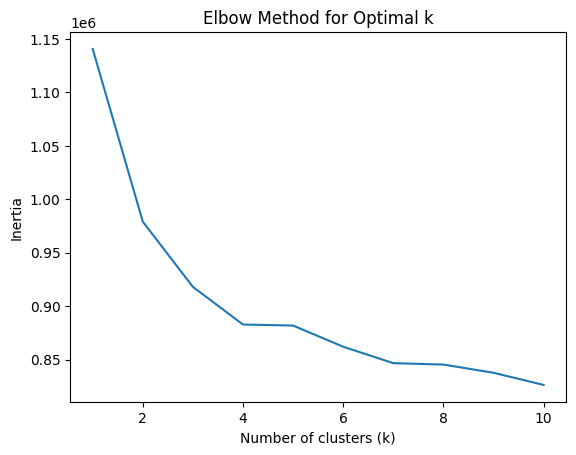

In [45]:
#choose the number of clusters k
#elbow method
#movies with similar ratings among similar users are clustered together

#apply k means with 5 clusters

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_mf_normalized)

#get cluster label from each movie
movie_cluster = kmeans.labels_

#plot elbow method to determine best k

inertia = []
for k in range(1, 11): #k=1 to k=10
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_mf_normalized)
  inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

### Choosing the Number of Clusters

The elbow method was used to evaluate different values of `k`. The plot shows a noticeable bend around **k = 3**, suggesting that three clusters may provide a reasonable balance between within-cluster similarity and model complexity.


In [46]:
#choose k = 3 based on the elbow method

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_mf_normalized)

movie_clusters = kmeans.labels_

print("Cluster assignments for movies:")

for i, cluster in enumerate(movie_clusters[:10]):
    print(f"Movie {i+1} is in Cluster {cluster}")

Cluster assignments for movies:
Movie 1 is in Cluster 2
Movie 2 is in Cluster 2
Movie 3 is in Cluster 0
Movie 4 is in Cluster 2
Movie 5 is in Cluster 0
Movie 6 is in Cluster 2
Movie 7 is in Cluster 2
Movie 8 is in Cluster 0
Movie 9 is in Cluster 2
Movie 10 is in Cluster 2


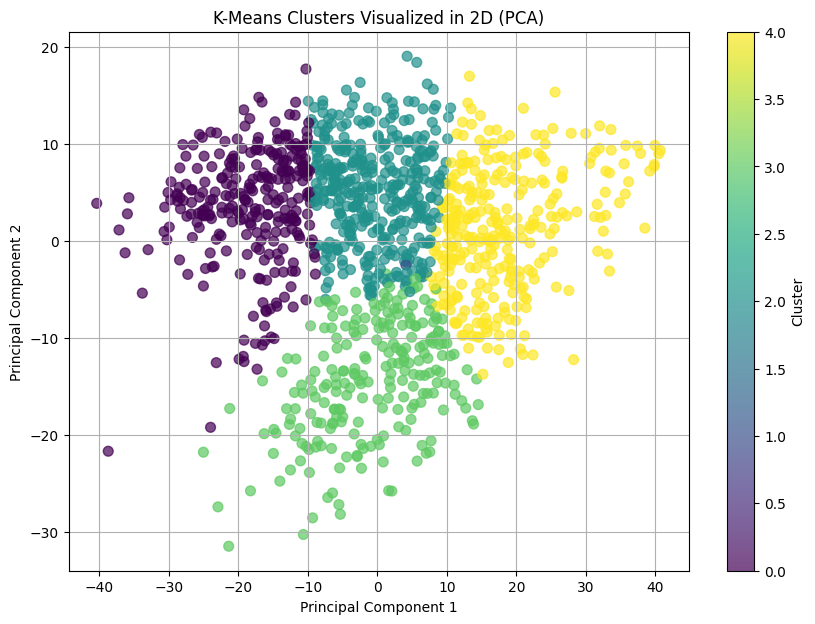

In [47]:
#visualize #dimension reduction using PCA

#apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_mf_normalized)

#plot clusters

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=movie_cluster, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters Visualized in 2D (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Conclusion

This project used matrix factorization to estimate missing movie ratings and K-Means clustering to identify groups of movies with similar rating patterns. PCA was then used to visualize the resulting clusters in two dimensions.

The matrix factorization model achieved an RMSE of **0.503** when compared with the complete ratings. The clustering analysis provided a way to explore similarities between movies based on user rating patterns.
